To create the environment:
`cd merc_module`
`uv venv`
`uv sync`

To update the container for changes to package list:
`docker compose build --no-cache`

To launch jupyter with the environment:
`uv run --with jupyter jupyter lab`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import os
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor

sb.set_style("darkgrid")
pal = sb.color_palette()
pal

[(0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 (1.0, 0.4980392156862745, 0.054901960784313725),
 (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
 (0.8392156862745098, 0.15294117647058825, 0.1568627450980392),
 (0.5803921568627451, 0.403921568627451, 0.7411764705882353),
 (0.5490196078431373, 0.33725490196078434, 0.29411764705882354),
 (0.8901960784313725, 0.4666666666666667, 0.7607843137254902),
 (0.4980392156862745, 0.4980392156862745, 0.4980392156862745),
 (0.7372549019607844, 0.7411764705882353, 0.13333333333333333),
 (0.09019607843137255, 0.7450980392156863, 0.8117647058823529)]

In [2]:
runtimes = pd.read_csv("../runtime.csv", header=None)
runtimes.columns = ["dir", "machine", "time", "niter", "nobj", "user", "runtime"]
for c in ["time", "niter", "nobj", "runtime"]:
    runtimes[c] = runtimes[c].astype("int")
runtimes["years"] = 10**runtimes["time"]
runtimes["obj_x_years"] = runtimes["years"] * runtimes["nobj"]
runtimes["runtime_per_obj_x_years"] = runtimes["runtime"] / runtimes["obj_x_years"]
runtimes = runtimes.sort_values(["time","nobj","runtime"])
runtimes

,dir,machine,time,niter,nobj,user,runtime,years,obj_x_years,runtime_per_obj_x_years
0,NewSim1,basil,1,1,1,no,1,10,10,0.100000
5,NewSim1,basil,1,1,1,no,2,10,10,0.200000
1,NewSim1,basil,1,1,10,no,1,10,100,0.010000
2,NewSim1,basil,1,1,100,no,1,10,1000,0.001000
3,NewSim1,basil,1,1,1000,no,5,10,10000,0.000500
4,NewSim1,basil,1,1,10000,no,37,10,100000,0.000370
6,NewSim1,basil,2,1,1,no,2,100,100,0.020000
7,NewSim1,basil,2,1,10,no,1,100,1000,0.001000
8,NewSim1,basil,2,1,100,no,5,100,10000,0.000500
9,NewSim1,basil,2,1,1000,no,34,100,100000,0.000340


In [3]:
outliers = (runtimes["nobj"] < 100) | ((runtimes["time"] == 1) & (runtimes["nobj"] <= 100)) 
runtimes.loc[outliers]

,dir,machine,time,niter,nobj,user,runtime,years,obj_x_years,runtime_per_obj_x_years
0,NewSim1,basil,1,1,1,no,1,10,10,0.100000
5,NewSim1,basil,1,1,1,no,2,10,10,0.200000
1,NewSim1,basil,1,1,10,no,1,10,100,0.010000
2,NewSim1,basil,1,1,100,no,1,10,1000,0.001000
6,NewSim1,basil,2,1,1,no,2,100,100,0.020000
7,NewSim1,basil,2,1,10,no,1,100,1000,0.001000
20,ScalingTestSim1,basil,3,1,1,no,4,1000,1000,0.004000
19,ScalingTestSim1,basil,3,1,10,no,8,1000,10000,0.000800
21,ScalingTestSim1,basil,4,1,1,no,32,10000,10000,0.003200
12,ScalingTestSim1,basil,4,1,10,no,58,10000,100000,0.000580


In [4]:
### Modeling parameters
X = np.log10(runtimes.loc[~outliers, ["years", "nobj"]])
y = np.log10(runtimes.loc[~outliers, "runtime"])


    coef=[0.94711038 0.93058959], 
    intercept=-3.0969418337849173,
0.9991083007759175


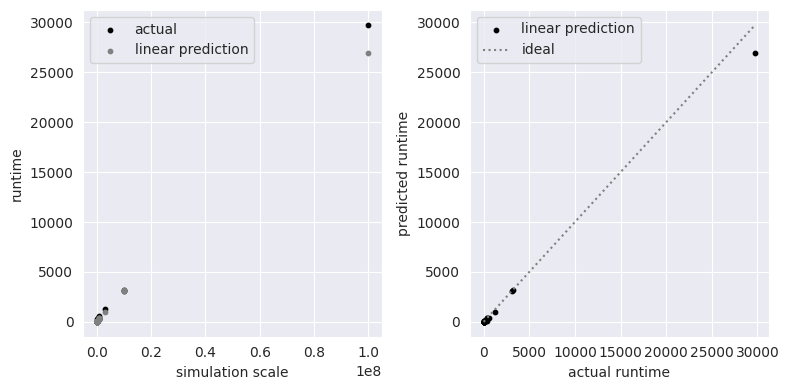

In [5]:
### Fit a linear model
reg = LinearRegression().fit(X, y)
print(f"""
    coef={reg.coef_}, 
    intercept={reg.intercept_},""")
print(reg.score(X, y))
runtimes["pred_lr"] = 10**reg.predict(np.log10(runtimes[["years", "nobj"]]))

### Visualize prediction performance
f1, ax1 = plt.subplots(1, 2, figsize=[8,4])
i=0
ax1[i].scatter(runtimes["obj_x_years"], runtimes["runtime"], s=10, c="black", label="actual")
ax1[i].scatter(runtimes["obj_x_years"], runtimes["pred_lr"], s=10, c="gray", label="linear prediction")
ax1[i].legend()
ax1[i].set_xlabel("simulation scale")
ax1[i].set_ylabel("runtime")

i=1
ax1[i].scatter(runtimes["runtime"], runtimes["pred_lr"], s=10, c="black", label="linear prediction")
ax1[i].plot([1, runtimes[["runtime", "pred_lr"]].max().max()], 
           [1, runtimes[["runtime", "pred_lr"]].max().max()], ls=":", c="gray", label="ideal")
ax1[i].legend()
ax1[i].set_xlabel("actual runtime")
ax1[i].set_ylabel("predicted runtime")

plt.tight_layout()


In [6]:
def estimate_runtime(
    time, 
    nobj, 
    coef=[0.90390841, 0.82615467], 
    intercept=-2.666868253789572,
):
    return 10**(intercept + np.log10(time)*coef[0] + np.log10(nobj)*coef[1])
    
### Scope out full run
goal_obj = 40000
sim_obj = 30
sim_runtime = estimate_runtime(1e7, sim_obj) / 3600

n_sims = goal_obj / sim_obj
total_runtime = sim_runtime * n_sims
print(f"""
{n_sims:.0f} sims ({sim_obj} rocks per sim) 
    at {sim_runtime:.1f} hours each 
    = {total_runtime:.1f} hours total for {goal_obj} particles total""")


1333 sims (30 rocks per sim) 
    at 21.1 hours each 
    = 28148.6 hours total for 40000 particles total


0.9999963496524099


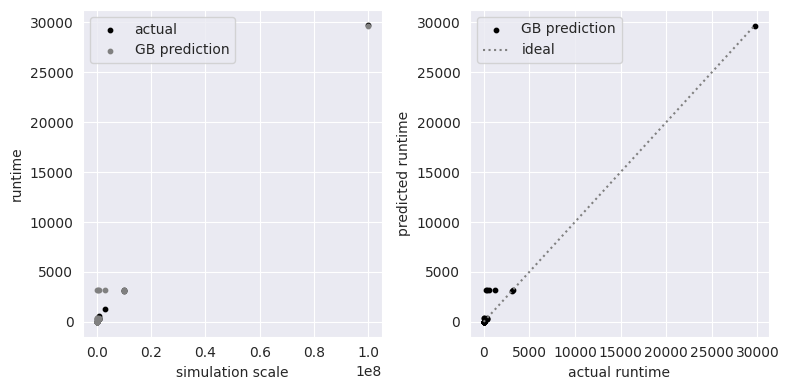

In [7]:
### Fit a non-linear model
gbr = GradientBoostingRegressor().fit(X, y)
# print(f"""
#     coef={gbr.coef_}, 
#     intercept={gbr.intercept_},""")
print(gbr.score(X, y))
runtimes["pred_gb"] = 10**gbr.predict(np.log10(runtimes[["years", "nobj"]]))

### Visualize prediction performance
f1, ax1 = plt.subplots(1, 2, figsize=[8,4])
i=0
ax1[i].scatter(runtimes["obj_x_years"], runtimes["runtime"], s=10, c="black", label="actual")
ax1[i].scatter(runtimes["obj_x_years"], runtimes["pred_gb"], s=10, c="gray", label="GB prediction")
ax1[i].legend()
ax1[i].set_xlabel("simulation scale")
ax1[i].set_ylabel("runtime")

i=1
ax1[i].scatter(runtimes["runtime"], runtimes["pred_gb"], s=10, c="black", label="GB prediction")
ax1[i].plot([1, runtimes[["runtime", "pred_gb"]].max().max()], 
           [1, runtimes[["runtime", "pred_gb"]].max().max()], ls=":", c="gray", label="ideal")
ax1[i].legend()
ax1[i].set_xlabel("actual runtime")
ax1[i].set_ylabel("predicted runtime")

plt.tight_layout()
### GB model looks better at the long end, but a mess on the short end

In [8]:
### well this looks awful
# def estimate_runtime(
#     time, 
#     nobj, 
#     coef=[0.90390841, 0.82615467], 
#     intercept=-2.666868253789572,
# ):
#     return 10**gbr.predict(np.log10(pd.DataFrame({"years": time,
#                                                   "nobj": nobj})))
#     # return 10**(intercept + np.log10(time)*coef[0] + np.log10(nobj)*coef[1])

# ### Scope out full run
# goal_obj = 40000
# sim_obj = 30
# sim_runtime = estimate_runtime(1e7, sim_obj) / 3600

# n_sims = goal_obj / sim_obj
# total_runtime = sim_runtime * n_sims
# print(f"""
# {n_sims:.0f} sims ({sim_obj} rocks per sim) 
#     at {sim_runtime:.1f} hours each 
#     = {total_runtime:.1f} hours total for {goal_obj} particles total""")

In [9]:
obj_years_x = np.arange(1, 1e7, 1000)
one_obj_y = estimate_runtime(obj_years_x, 1)
one_year_y = estimate_runtime(1, obj_years_x)

full_sim_x = np.arange(1, 1e5, 1000)
full_sim_y = estimate_runtime(full_sim_x, 1e7)

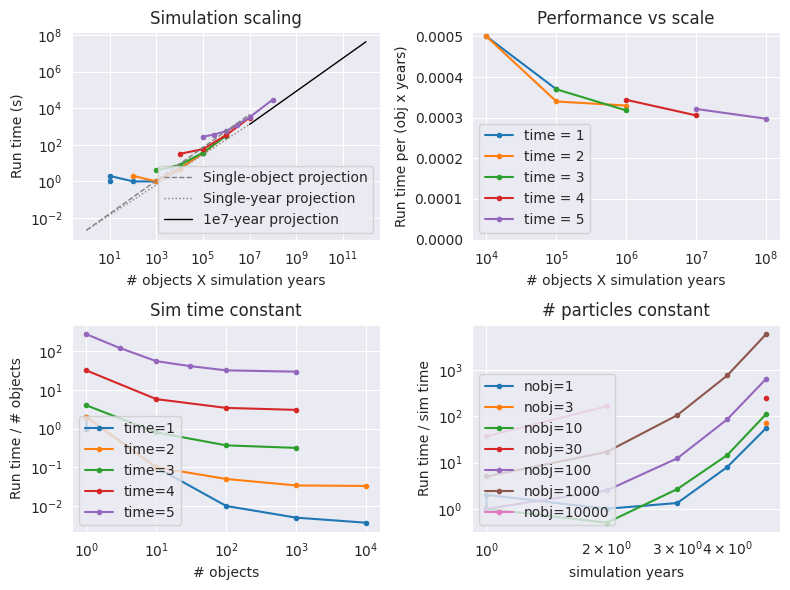

In [10]:
f1, ax1 = plt.subplots(2, 2, figsize=[8, 6])

i=0,0
ax1[i].set_title("Simulation scaling")
ax1[i].set_xlabel("# objects X simulation years")
ax1[i].set_ylabel("Run time (s)")
for _, t in enumerate(runtimes["time"].unique()):
    tmp = runtimes.loc[runtimes["time"] == t]
    ax1[i].plot(tmp["obj_x_years"], tmp["runtime"], marker="o", ms=3)

ax1[i].plot(obj_years_x, one_obj_y, lw=1, c="gray", ls="--", label="Single-object projection")
ax1[i].plot(obj_years_x, one_year_y, lw=1, c="gray", ls=":", label="Single-year projection")
ax1[i].plot(1e7*full_sim_x, full_sim_y, lw=1, c="black", label="1e7-year projection")
ax1[i].legend(loc="lower right")
ax1[i].set_xscale("log")
ax1[i].set_yscale("log")

i=0,1
ax1[i].set_title("Performance vs scale")
ax1[i].set_xlabel("# objects X simulation years")
ax1[i].set_ylabel("Run time per (obj x years)")
for _, t in enumerate(runtimes["time"].unique()):
    tmp = runtimes.loc[(runtimes["time"] == t) & ~outliers]
    ax1[i].plot(tmp["obj_x_years"], tmp["runtime_per_obj_x_years"], marker="o", ms=3, label=f"time = {t}")
ax1[i].legend()
ax1[i].set_ylim([0, ax1[i].get_ylim()[-1]])
ax1[i].set_xscale("log")

i=1,0
ax1[i].set_title("Sim time constant")
for _, t in enumerate(runtimes["time"].unique()):
    tmp = runtimes.loc[(runtimes["time"] == t)].sort_values("nobj")
    ax1[i].plot(tmp["nobj"], tmp["runtime"]/tmp["nobj"], marker="o", ms=3, label=f"time={t}")
ax1[i].set_xlabel("# objects")
ax1[i].set_ylabel("Run time / # objects")
ax1[i].legend(loc="lower left")
ax1[i].set_xscale("log")
ax1[i].set_yscale("log")

i=1,1
ax1[i].set_title("# particles constant")
for _, n in enumerate(sorted(runtimes["nobj"].unique())):
    tmp = runtimes.loc[(runtimes["nobj"] == n)].sort_values("time")
    ax1[i].plot(tmp["time"], tmp["runtime"]/tmp["time"], marker="o", ms=3, label=f"nobj={n}")
ax1[i].set_xlabel("simulation years")
ax1[i].set_ylabel("Run time / sim time")
ax1[i].legend(loc="lower left")
ax1[i].set_xscale("log")
ax1[i].set_yscale("log")

plt.tight_layout()
f1.savefig("scaling.png")

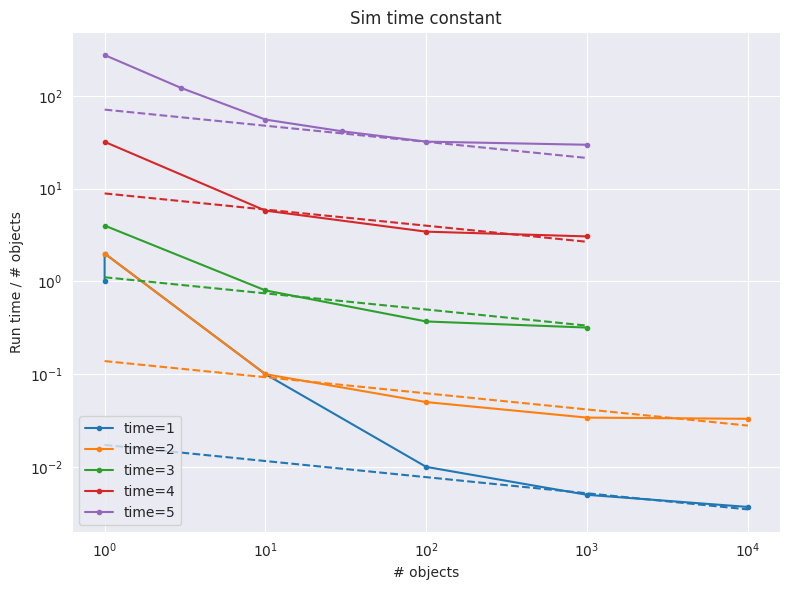

In [11]:
f1, ax1 = plt.subplots(1, figsize=[8,6])

ax1.set_title("Sim time constant")
for i, t in enumerate(runtimes["time"].unique()):
    tmp = runtimes.loc[(runtimes["time"] == t)].sort_values("nobj")
    ax1.plot(tmp["nobj"], tmp["runtime"]/tmp["nobj"], marker="o", ms=3, c=pal[i], label=f"time={t}")
    ax1.plot(tmp["nobj"], estimate_runtime(10**t, tmp["nobj"])/tmp["nobj"], ls="--", c=pal[i])
ax1.set_xlabel("# objects")
ax1.set_ylabel("Run time / # objects")
ax1.legend(loc="lower left")
ax1.set_xscale("log")
ax1.set_yscale("log")

plt.tight_layout()
